In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_parquet("perm_visas_clean.parquet")

In [16]:
df_model['case_received_date'] = pd.to_datetime(df_model['case_received_date'], errors='coerce')
df_model['decision_date'] = pd.to_datetime(df_model['decision_date'], errors='coerce')
df_model['processing_days'] = (df_model['decision_date'] - df_model['case_received_date']).dt.days

df_model = df_model[df_model['processing_days'] >= 0]

In [17]:
X2 = pd.get_dummies(
    df_model[['log_employer_size', 'wage_10k', 'pw_level_9089',
              'job_info_education', 'decision_year']],
    columns=['pw_level_9089', 'job_info_education'],
    drop_first=True
).astype(float)
X2 = sm.add_constant(X2)
y2 = df_model['success']

audit_model = sm.OLS(y2, X2).fit(cov_type='HC3')
print(audit_model.summary())

                            OLS Regression Results                            
Dep. Variable:                success   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     119.8
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          3.66e-274
Time:                        14:00:05   Log-Likelihood:                 32744.
No. Observations:              100269   AIC:                        -6.546e+04
Df Residuals:                  100257   BIC:                        -6.535e+04
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

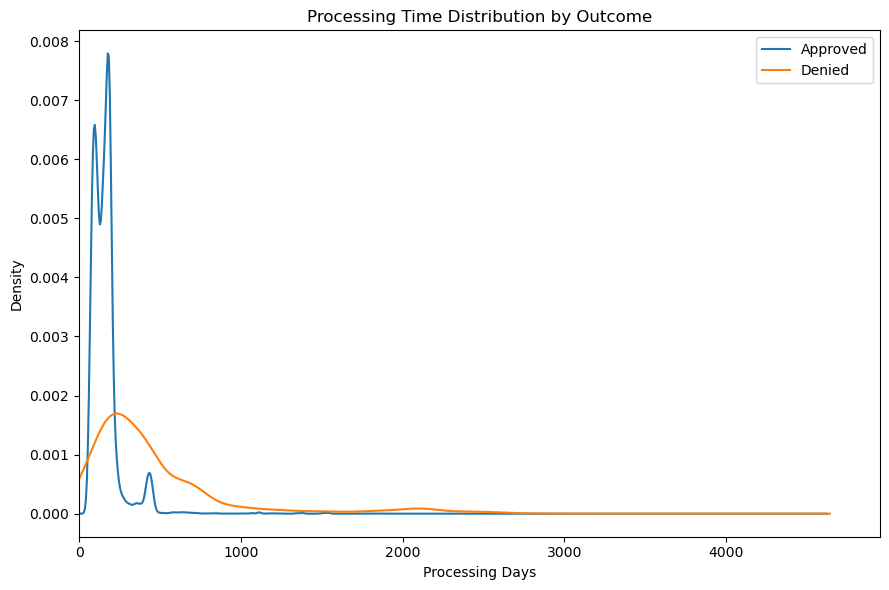

In [19]:
plt.figure(figsize=(9, 6))
df_model[df_model['success'] == 1]['processing_days'].plot(kind='kde', label='Approved')
df_model[df_model['success'] == 0]['processing_days'].plot(kind='kde', label='Denied')
plt.xlabel("Processing Days")
plt.ylabel("Density")
plt.title("Processing Time Distribution by Outcome")
plt.legend()
plt.xlim(left=0)
plt.tight_layout()
plt.show()